In [14]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

In [15]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "diabetes.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "mathchi/diabetes-data-set",
  file_path,
)

print("First 5 records:", df.head())

/var/folders/pv/j2t8qmzs1wqbsr9jfqpvl8p80000gn/T/ipykernel_22850/2996483295.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


First 5 records:    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [16]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']
feature_names = X.columns.tolist()
print(f'데이터셋: {X.shape}  |  당뇨(1): {y.sum()}  정상(0): {(y==0).sum()}')

데이터셋: (768, 8)  |  당뇨(1): 268  정상(0): 500


               결측(0) 개수  비율(%)
Glucose               5   0.65
BloodPressure        35   4.56
SkinThickness       227  29.56
Insulin             374  48.70
BMI                  11   1.43


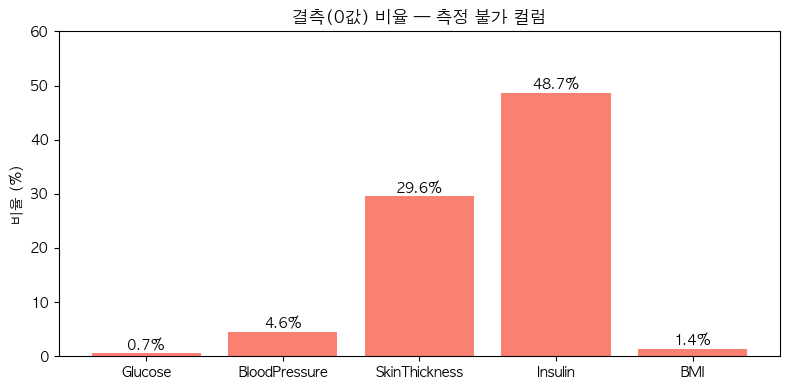

In [17]:
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
zero_counts = (df[zero_cols] == 0).sum()
zero_pct    = (df[zero_cols] == 0).mean() * 100
summary = pd.DataFrame({'결측(0) 개수': zero_counts, '비율(%)': zero_pct.round(2)})
print(summary)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(summary.index, summary['비율(%)'], color='salmon')
ax.set_ylabel('비율 (%)')
ax.set_title('결측(0값) 비율 — 측정 불가 컬럼')
ax.set_ylim(0, 60)
for i, v in enumerate(summary['비율(%)']):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

In [18]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

model_defs = {
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, learning_rate=0.1, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=4, random_state=42),
}

cv_results = {}
oof_preds = {}
oof_probs = {}

for name, model in model_defs.items():
    fold_acc, fold_auc, fold_sens, fold_spec = [], [], [], []
    oof_pred = np.zeros(len(X))
    oof_prob = np.zeros(len(X))

    for train_idx, test_idx in kf.split(X):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_tr, y_tr)
        pred = model.predict(X_te)
        prob = model.predict_proba(X_te)[:, 1]

        oof_pred[test_idx] = pred
        oof_prob[test_idx] = prob

        cm = confusion_matrix(y_te, pred)
        tn, fp, fn, tp = cm.ravel()

        fold_acc.append(accuracy_score(y_te, pred))
        fold_auc.append(roc_auc_score(y_te, prob))
        fold_sens.append(tp / (tp + fn))
        fold_spec.append(tn / (tn + fp))

    cv_results[name] = {
        'Accuracy':    (np.mean(fold_acc),  np.std(fold_acc)),
        'AUC':         (np.mean(fold_auc),  np.std(fold_auc)),
        'Sensitivity': (np.mean(fold_sens), np.std(fold_sens)),
        'Specificity': (np.mean(fold_spec), np.std(fold_spec)),
    }
    oof_preds[name] = oof_pred.astype(int)
    oof_probs[name] = oof_prob
    m = cv_results[name]
    print(f'[{name}]  Acc: {m["Accuracy"][0]:.4f}±{m["Accuracy"][1]:.4f}  AUC: {m["AUC"][0]:.4f}±{m["AUC"][1]:.4f}')

[Random Forest]  Acc: 0.7669±0.0216  AUC: 0.8279±0.0131
[AdaBoost]  Acc: 0.7578±0.0363  AUC: 0.8317±0.0257
[Decision Tree]  Acc: 0.7396±0.0293  AUC: 0.7961±0.0189


In [19]:
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X, y)

rf_full = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_full.fit(X, y)

ada_full = AdaBoostClassifier(n_estimators=200, learning_rate=0.1, random_state=42)
ada_full.fit(X, y)

,estimator,None
,n_estimators,200
,learning_rate,0.1
,algorithm,'deprecated'
,random_state,42


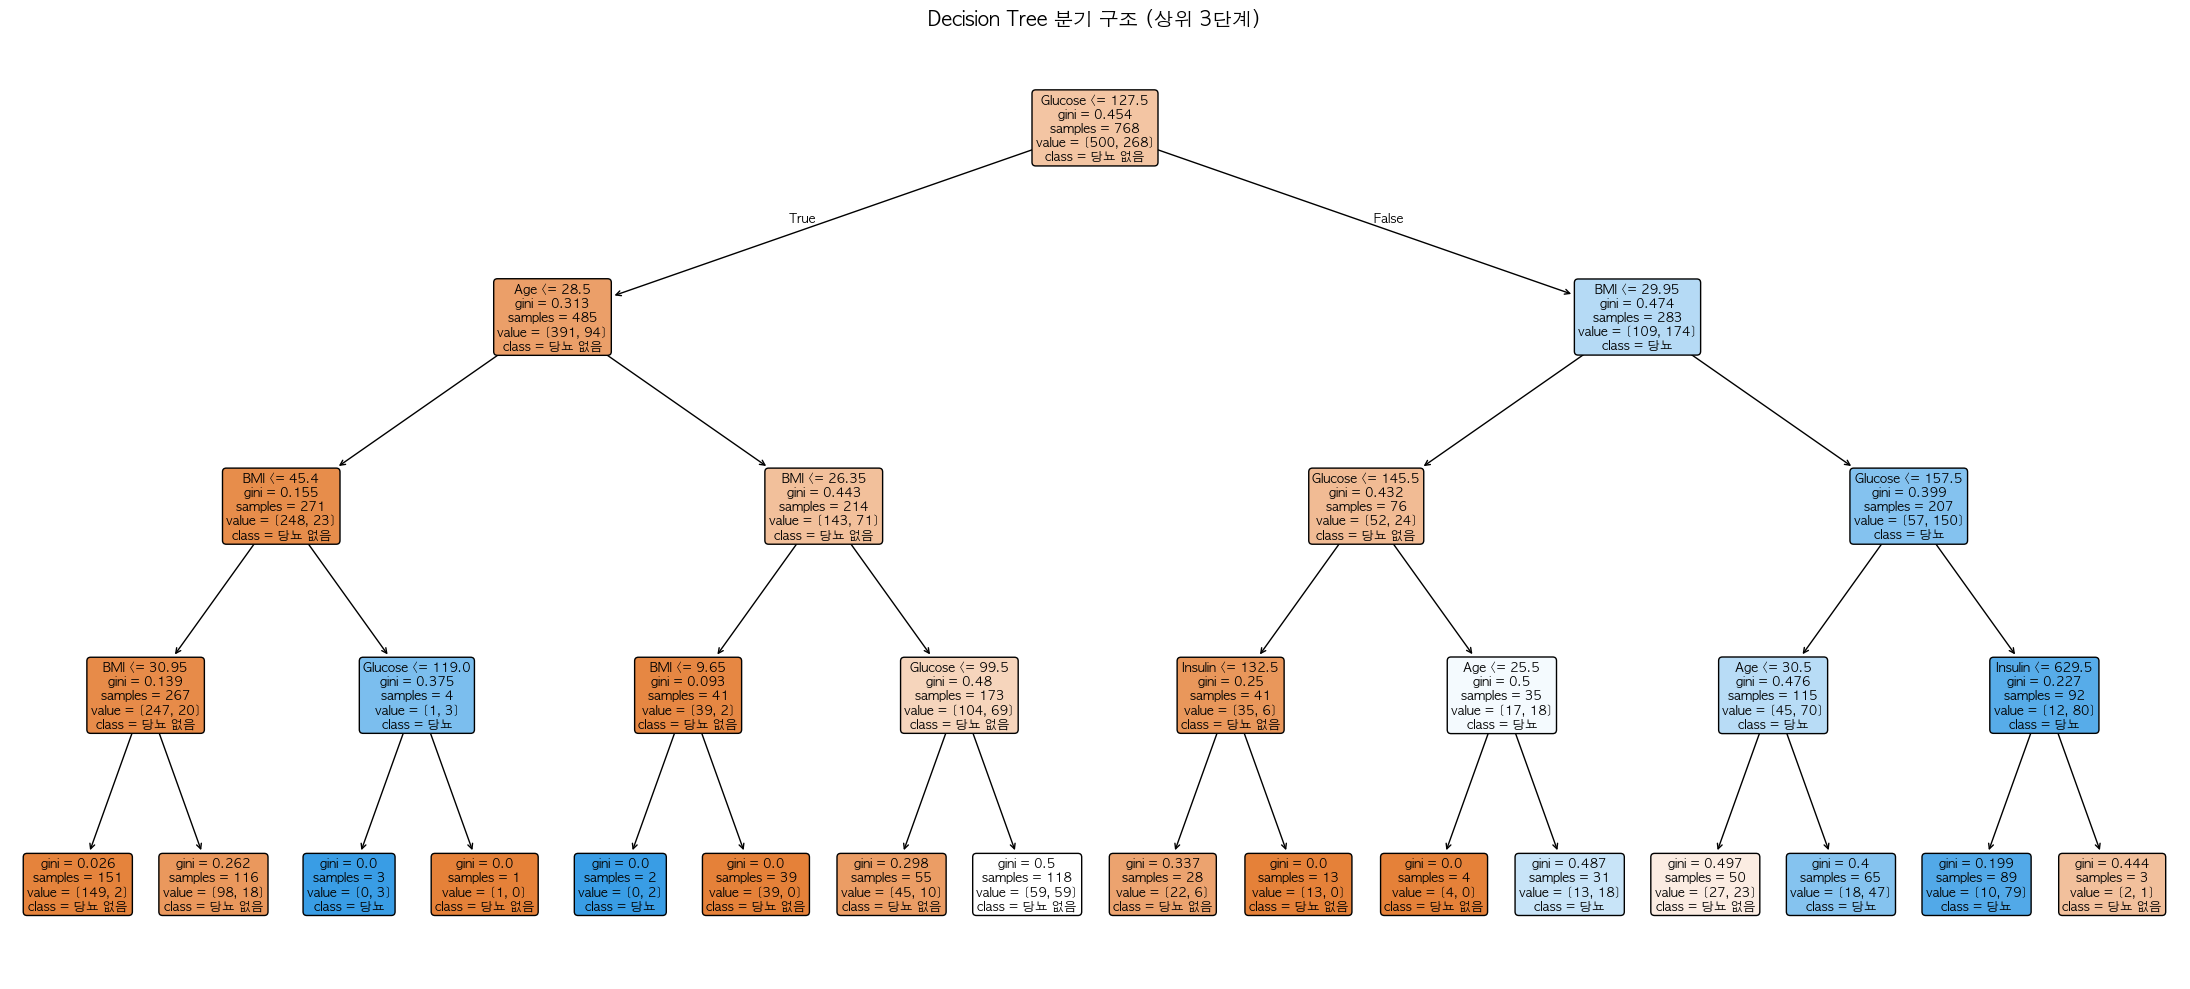

In [20]:
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    dt_model,
    feature_names=feature_names,
    class_names=['당뇨 없음', '당뇨'],
    filled=True,
    rounded=True,
    max_depth=4,
    ax=ax,
    fontsize=9
)
ax.set_title('Decision Tree 분기 구조 (상위 3단계)', fontsize=14)
plt.tight_layout()
plt.show()

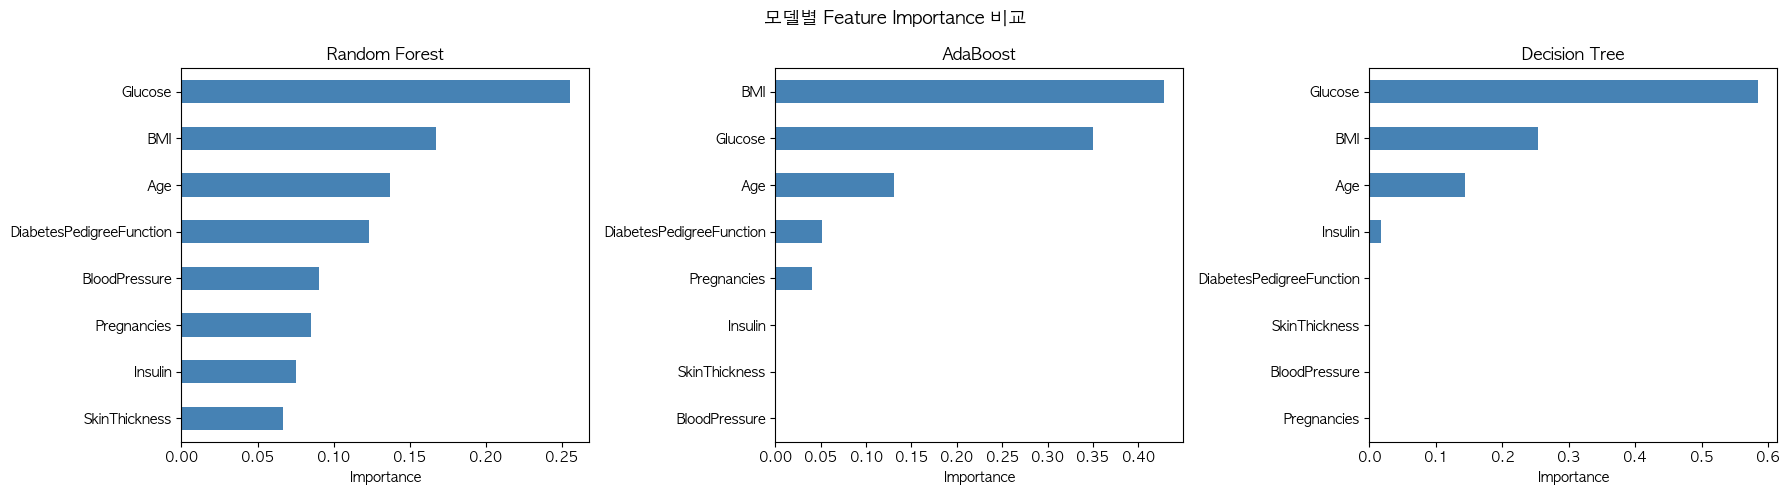


=== Feature Importance 순위 ===

[Random Forest]
Glucose                     0.255052
BMI                         0.166965
Age                         0.136767
DiabetesPedigreeFunction    0.123530
BloodPressure               0.090387
Pregnancies                 0.084833
Insulin                     0.075420
SkinThickness               0.067046

[AdaBoost]
BMI                         0.427977
Glucose                     0.349883
Age                         0.130914
DiabetesPedigreeFunction    0.051173
Pregnancies                 0.040053
BloodPressure               0.000000
SkinThickness               0.000000
Insulin                     0.000000

[Decision Tree]
Glucose                     0.583931
BMI                         0.253869
Age                         0.144246
Insulin                     0.017953
Pregnancies                 0.000000
BloodPressure               0.000000
SkinThickness               0.000000
DiabetesPedigreeFunction    0.000000


In [21]:
importance_models = [
    ('Random Forest', rf_full),
    ('AdaBoost',      ada_full),
    ('Decision Tree', dt_model),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, model) in zip(axes, importance_models):
    imp = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=True)
    imp.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{name}')
    ax.set_xlabel('Importance')

plt.suptitle('모델별 Feature Importance 비교', fontsize=13)
plt.tight_layout()
plt.show()

print("\n=== Feature Importance 순위 ===")
for name, model in importance_models:
    imp = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
    print(f"\n[{name}]")
    print(imp.to_string())

In [22]:
rows = []
for name, m in cv_results.items():
    rows.append({
        'Model':       name,
        'Accuracy':    f'{m["Accuracy"][0]:.4f} ± {m["Accuracy"][1]:.4f}',
        'AUC':         f'{m["AUC"][0]:.4f} ± {m["AUC"][1]:.4f}',
        'Sensitivity': f'{m["Sensitivity"][0]:.4f} ± {m["Sensitivity"][1]:.4f}',
        'Specificity': f'{m["Specificity"][0]:.4f} ± {m["Specificity"][1]:.4f}',
    })
results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))

        Model        Accuracy             AUC     Sensitivity     Specificity
Random Forest 0.7669 ± 0.0216 0.8279 ± 0.0131 0.5846 ± 0.0546 0.8652 ± 0.0413
     AdaBoost 0.7578 ± 0.0363 0.8317 ± 0.0257 0.5393 ± 0.0606 0.8754 ± 0.0255
Decision Tree 0.7396 ± 0.0293 0.7961 ± 0.0189 0.6400 ± 0.0786 0.7968 ± 0.0635


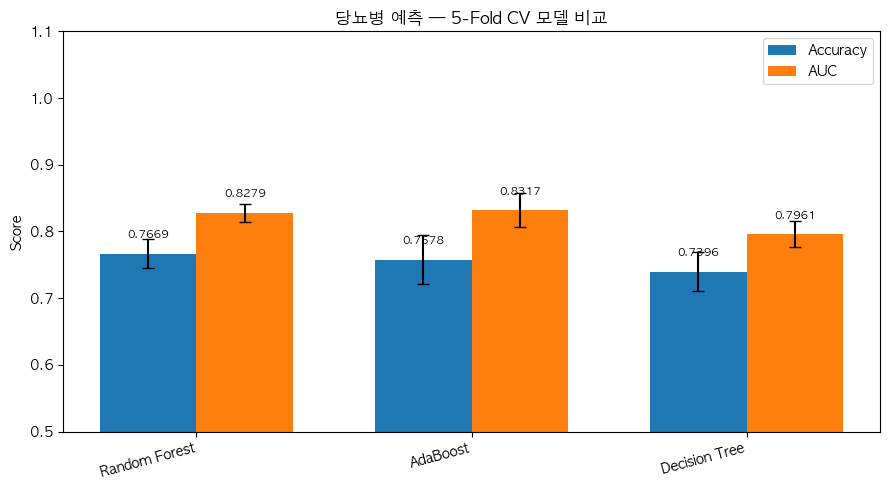

In [23]:
model_names = list(cv_results.keys())
metrics_to_plot = ['Accuracy', 'AUC']
x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
for i, metric in enumerate(metrics_to_plot):
    means = [cv_results[m][metric][0] for m in model_names]
    stds  = [cv_results[m][metric][1] for m in model_names]
    bars = ax.bar(x + (i - 0.5) * width, means, width, label=metric, yerr=stds, capsize=4)
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{mean:.4f}', ha='center', va='bottom', fontsize=8)

ax.set_ylim(0.5, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_title('당뇨병 예측 — 5-Fold CV 모델 비교')
ax.legend()
plt.tight_layout()
plt.show()

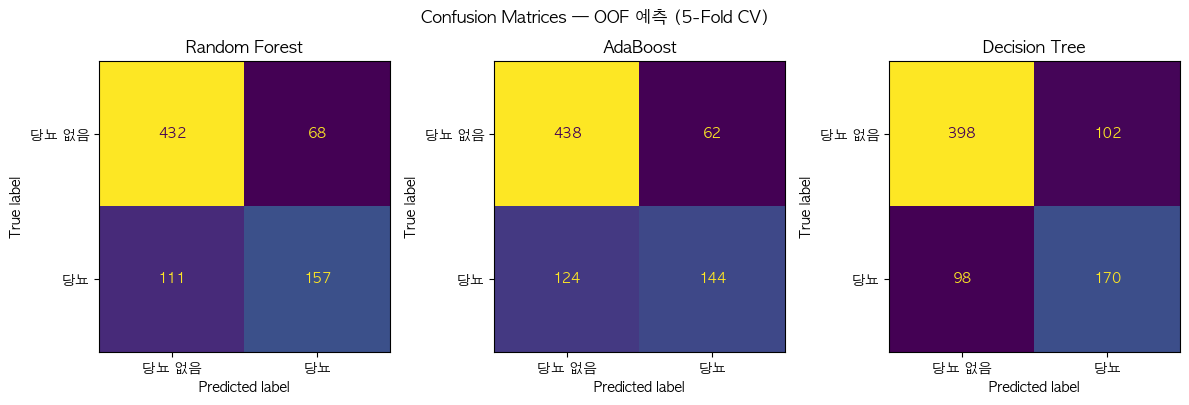

In [24]:
model_info = list(cv_results.keys())

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, name in zip(axes, model_info):
    cm = confusion_matrix(y, oof_preds[name])
    disp = ConfusionMatrixDisplay(cm, display_labels=['당뇨 없음', '당뇨'])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.suptitle('Confusion Matrices — OOF 예측 (5-Fold CV)')
plt.tight_layout()
plt.show()

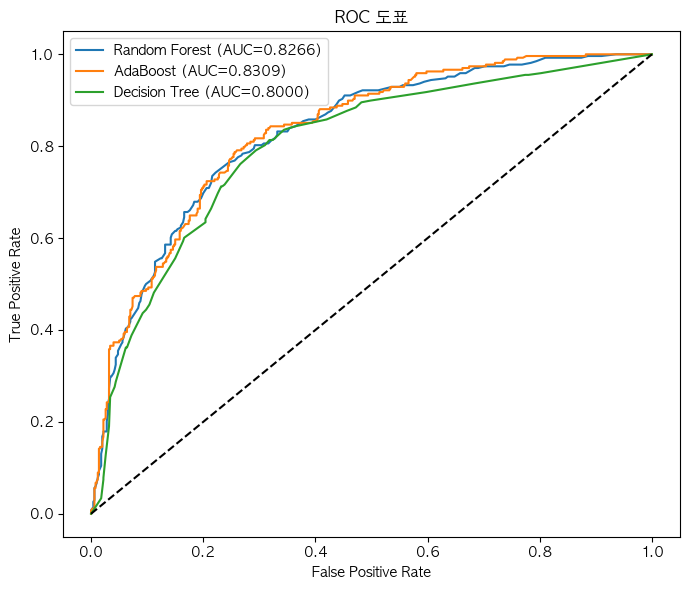

In [25]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(7, 6))
for name in model_info:
    fpr, tpr, _ = roc_curve(y, oof_probs[name])
    auc_val = roc_auc_score(y, oof_probs[name])
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC 도표')
ax.legend()
plt.tight_layout()
plt.show()

           모델 민감도(Sensitivity) 특이도(Specificity)
Random Forest  0.5846 ± 0.0546  0.8652 ± 0.0413
     AdaBoost  0.5393 ± 0.0606  0.8754 ± 0.0255
Decision Tree  0.6400 ± 0.0786  0.7968 ± 0.0635


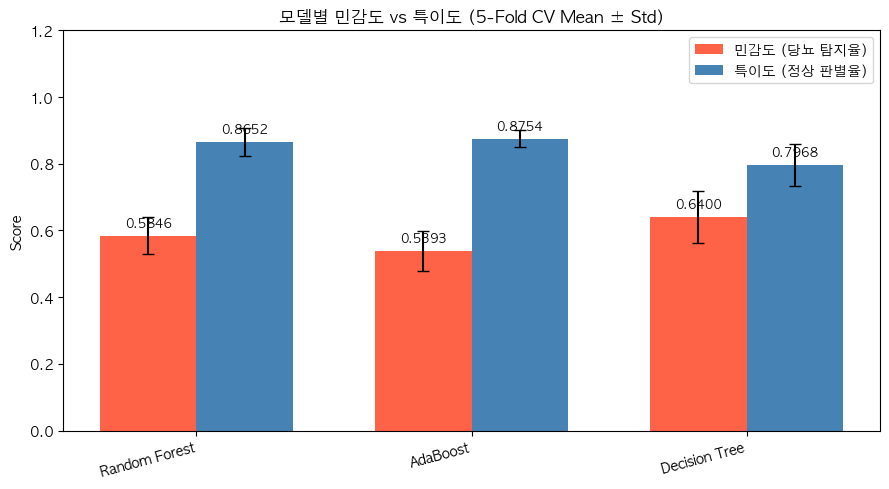

In [26]:
rows = []
for name, m in cv_results.items():
    rows.append({
        '모델': name,
        '민감도(Sensitivity)': f'{m["Sensitivity"][0]:.4f} ± {m["Sensitivity"][1]:.4f}',
        '특이도(Specificity)': f'{m["Specificity"][0]:.4f} ± {m["Specificity"][1]:.4f}',
    })
print(pd.DataFrame(rows).to_string(index=False))

model_names = list(cv_results.keys())
x = np.arange(len(model_names))
width = 0.35

sens_means = [cv_results[m]['Sensitivity'][0] for m in model_names]
sens_stds  = [cv_results[m]['Sensitivity'][1] for m in model_names]
spec_means = [cv_results[m]['Specificity'][0] for m in model_names]
spec_stds  = [cv_results[m]['Specificity'][1] for m in model_names]

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, sens_means, width, label='민감도 (당뇨 탐지율)', color='tomato',    yerr=sens_stds, capsize=4)
bars2 = ax.bar(x + width/2, spec_means, width, label='특이도 (정상 판별율)', color='steelblue', yerr=spec_stds, capsize=4)

for bar, val in zip(list(bars1) + list(bars2), sens_means + spec_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)

ax.set_ylim(0, 1.2)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_title('모델별 민감도 vs 특이도 (5-Fold CV Mean ± Std)')
ax.legend()
plt.tight_layout()
plt.show()